In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [88]:
df=pd.read_csv("Loan_default.csv")

In [89]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [91]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [92]:
df.isnull().sum()


LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

# Identify Target Variable

In [93]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [94]:
df['Default'].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

# Data Cleaning

In [95]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [96]:
df['Default'].unique()

array([0, 1])

In [97]:
df.groupby('Default')[[
    'CreditScore',
    'DTIRatio',
    'InterestRate',
    'Income',
    'LoanAmount'
]].mean().round(2)

,CreditScore,DTIRatio,InterestRate,Income,LoanAmount
Default,,,,,
0,576.23,0.50,13.18,83899.17,125353.66
1,559.29,0.51,15.90,71844.72,144515.31


In [98]:
df['Loan_to_Income'] = df['LoanAmount'] / df['Income']

In [99]:
df.groupby('Default')['Loan_to_Income'].mean().round(3)

Default
0    2.036
1    3.253
Name: Loan_to_Income, dtype: float64

In [100]:
def risk_segment(row):
    if row['Loan_to_Income'] > 3:
        return "High Risk"
    elif row['Loan_to_Income'] > 2:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Risk_Level'] = df.apply(risk_segment, axis=1)

In [101]:
df.groupby('Risk_Level')['Default'].mean().round(3)

Risk_Level
High Risk      0.197
Low Risk       0.090
Medium Risk    0.112
Name: Default, dtype: float64

In [102]:
def advanced_risk(row):
    if row['Loan_to_Income'] > 3 and row['CreditScore'] < 570:
        return "Very High Risk"
    elif row['Loan_to_Income'] > 3:
        return "High Risk"
    elif row['CreditScore'] < 570:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Advanced_Risk'] = df.apply(advanced_risk, axis=1)

In [103]:
df.groupby('Advanced_Risk')['Default'].mean().round(3)

Advanced_Risk
High Risk         0.186
Low Risk          0.086
Medium Risk       0.102
Very High Risk    0.210
Name: Default, dtype: float64

In [104]:
pd.crosstab(df['EmploymentType'], df['Default'], normalize='index').round(3)

Default,0,1
EmploymentType,,
Full-time,0.905,0.095
Part-time,0.880,0.120
Self-employed,0.885,0.115
Unemployed,0.864,0.136


In [105]:
df['DTI_Category'] = pd.cut(df['DTIRatio'],
                            bins=[0, 0.3, 0.5, 0.7, 1],
                            labels=['Low DTI', 'Moderate DTI', 'High DTI', 'Very High DTI'])

pd.crosstab(df['DTI_Category'], df['Default'], normalize='index').round(3)

Default,0,1
DTI_Category,,
Low DTI,0.893,0.107
Moderate DTI,0.885,0.115
High DTI,0.880,0.120
Very High DTI,0.877,0.123


In [106]:
correlation = df[['Default',
                  'CreditScore',
                  'Loan_to_Income',
                  'DTIRatio',
                  'InterestRate',
                  'Income',
                  'LoanAmount']].corr()

correlation['Default'].sort_values(ascending=False)

Default           1.000000
Loan_to_Income    0.178963
InterestRate      0.131273
LoanAmount        0.086659
DTIRatio          0.019236
CreditScore      -0.034166
Income           -0.099119
Name: Default, dtype: float64

# Loan_to_Income vs Default

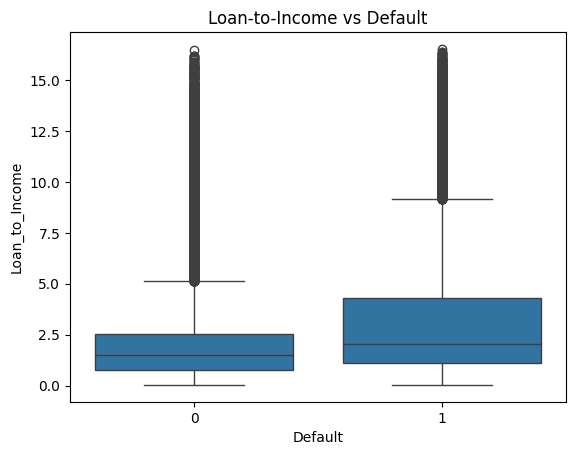

In [107]:
sns.boxplot(x='Default', y='Loan_to_Income', data=df)
plt.title("Loan-to-Income vs Default")
plt.show()

# CreditScore vs Default

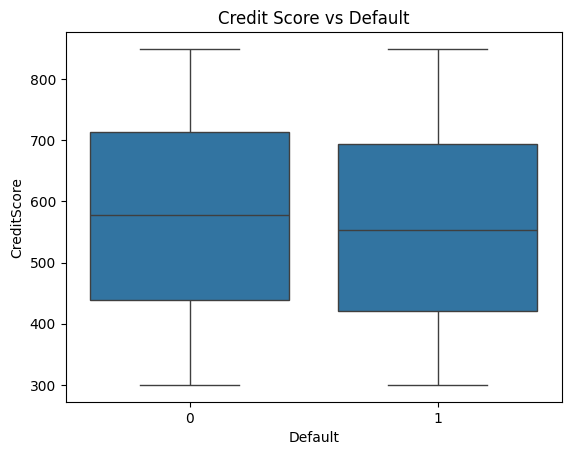

In [108]:
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Default")
plt.show()

In [109]:
X = df[['Loan_to_Income', 'CreditScore', 'InterestRate', 'Income']]
y = df['Default']

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [111]:
model = LogisticRegression(max_iter=1000)

In [112]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [113]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

importance

,Feature,Coefficient
0,Loan_to_Income,1.981798e-01
2,InterestRate,6.544087e-02
3,Income,2.886068e-07
1,CreditScore,-7.166809e-04


In [114]:
y_pred = model.predict(X_test)

In [117]:
accuracy = accuracy_score(y_test, y_pred) * 100
print("Accuracy: {:.2f}%".format(accuracy))

Accuracy: 88.42%


In [119]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67681
           1       0.56      0.03      0.05      8924

    accuracy                           0.88     76605
   macro avg       0.72      0.51      0.49     76605
weighted avg       0.85      0.88      0.83     76605



In [118]:
print(confusion_matrix(y_test, y_pred))

[[67497   184]
 [ 8689   235]]


In [120]:
#df.to_csv("final_loan_analysis.csv", index=False)

In [121]:
total_customers = len(df)
total_defaults = df['Default'].sum()
default_rate = (total_defaults / total_customers) * 100
high_risk_rate = df[df['Advanced_Risk'] == "Very High Risk"].shape[0] / total_customers * 100

print(f"Total Customers: {total_customers}")
print(f"Total Defaults: {total_defaults}")
print(f"Overall Default Rate: {default_rate:.2f}%")
print(f"Very High Risk Customers: {high_risk_rate:.2f}%")

Total Customers: 255347
Total Defaults: 29653
Overall Default Rate: 11.61%
Very High Risk Customers: 10.44%


# Executive Summary

1) Total Customers: 255,347

2) Default Rate: 11.6%

3) Very High Risk default rate: 21%

4) Strongest predictor: Loan-to-Income ratio

5) Unemployed applicants show highest behavioral risk

6) Higher interest rate associated with higher default

# Business Recommendations

1) Introduce stricter approval for Loan-to-Income > 3

2) Implement risk-based pricing strategy

3) Apply enhanced verification for unemployed applicants

4) Monitor high DTI customers for early intervention

5) Build internal risk scoring model using Loan-to-Income + Credit Score

In [122]:
df.to_csv("final_loan_analysis.csv", index=False)